# Desafío - Prediciendo los precios de las casas
## Daniel Rojas López

### Descripción del problema de negocio

Se trabaja para una importante empresa de propiedades que dispone de un registro histórico de **21.613 casas vendidas** en el área de King County (Estados Unidos), con **21 características** de cada propiedad (superficies, número de habitaciones, ubicación, antigüedad, entre otras) y su **precio de venta**.

- **Unidad de análisis:** cada casa vendida (una fila por propiedad).
- **Variable objetivo:** `price` (precio de venta en dólares).
- **Tipo de problema:** regresión supervisada (predecir un valor continuo).
- **Objetivo:** construir un modelo capaz de predecir el precio de una casa a partir de sus características, evaluando el desempeño con las métricas **MSE, MAE y R²**.
- **Metodología:** inspección y limpieza de datos, análisis descriptivo y de correlaciones, división entrenamiento/prueba, transformación de variables, modelamiento con regresión regularizada (Ridge, Lasso, Elastic Net) y árboles de regresión, ajuste de hiperparámetros y evaluación final.

In [1]:
# Se importarán las librerías necesarias para el análisis, la visualización y el modelamiento.
%matplotlib inline
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Se configurarán la semilla de reproducibilidad, el estilo de las gráficas y los filtros de avisos.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 1 - Análisis de calidad de datos y limpieza

En esta actividad se cargan los datos, se inspecciona su estructura y calidad (tipos, nulos, duplicados y atípicos) y se construye una función reutilizable de limpieza para dejar los datos listos para modelar.

In [2]:
# Se cargarán los datos desde el archivo house_data.xlsx y se mostrará una muestra de los registros.
df = pd.read_excel('house_data.xlsx')
print('Dimensiones (filas, columnas):', df.shape)
df.head()

Dimensiones (filas, columnas): (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# Se revisarán los tipos de datos, valores nulos y filas duplicadas del dataset original.
print('Tipos de datos:\n')
print(df.dtypes.to_string())
print('\nValores nulos por columna:\n')
print(df.isna().sum().to_string())
print('\nTotal de valores nulos:', df.isna().sum().sum())
print('Filas duplicadas:', df.duplicated().sum())

Tipos de datos:

id                 int64
date                 str
price              int64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64

Valores nulos por columna:

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0

Total de valores nulos: 0
Fil

In [4]:
# Se calculará el número de atípicos por variable numérica mediante el método del rango intercuartílico (IQR).
def detectar_outliers_iqr(datos, columna):
    q1, q3 = datos[columna].quantile(0.25), datos[columna].quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = datos[(datos[columna] < lim_inf) | (datos[columna] > lim_sup)]
    return outliers, lim_inf, lim_sup

# Se evaluarán las variables de tamaño, precio y ubicación (se excluyen las ordinales y el año de renovación con ceros no informativos).
columnas_continuas = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                      'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'lat', 'long']
for col in columnas_continuas:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
    if len(outliers) > 0:
        print(f'{col}: {len(outliers)} atípicos (límite inferior {lim_inf:,.1f}, superior {lim_sup:,.1f})')

price: 1146 atípicos (límite inferior -162,625.0, superior 1,129,575.0)
bedrooms: 546 atípicos (límite inferior 1.5, superior 5.5)
bathrooms: 571 atípicos (límite inferior 0.6, superior 3.6)
sqft_living: 572 atípicos (límite inferior -257.5, superior 4,234.5)
sqft_lot: 2425 atípicos (límite inferior -3,432.0, superior 19,160.0)
sqft_above: 611 atípicos (límite inferior -340.0, superior 3,740.0)
sqft_basement: 496 atípicos (límite inferior -840.0, superior 1,400.0)
sqft_living15: 544 atípicos (límite inferior 185.0, superior 3,665.0)
sqft_lot15: 2194 atípicos (límite inferior -2,374.5, superior 17,557.5)
lat: 2 atípicos (límite inferior 47.2, superior 48.0)
long: 256 atípicos (límite inferior -122.6, superior -121.8)


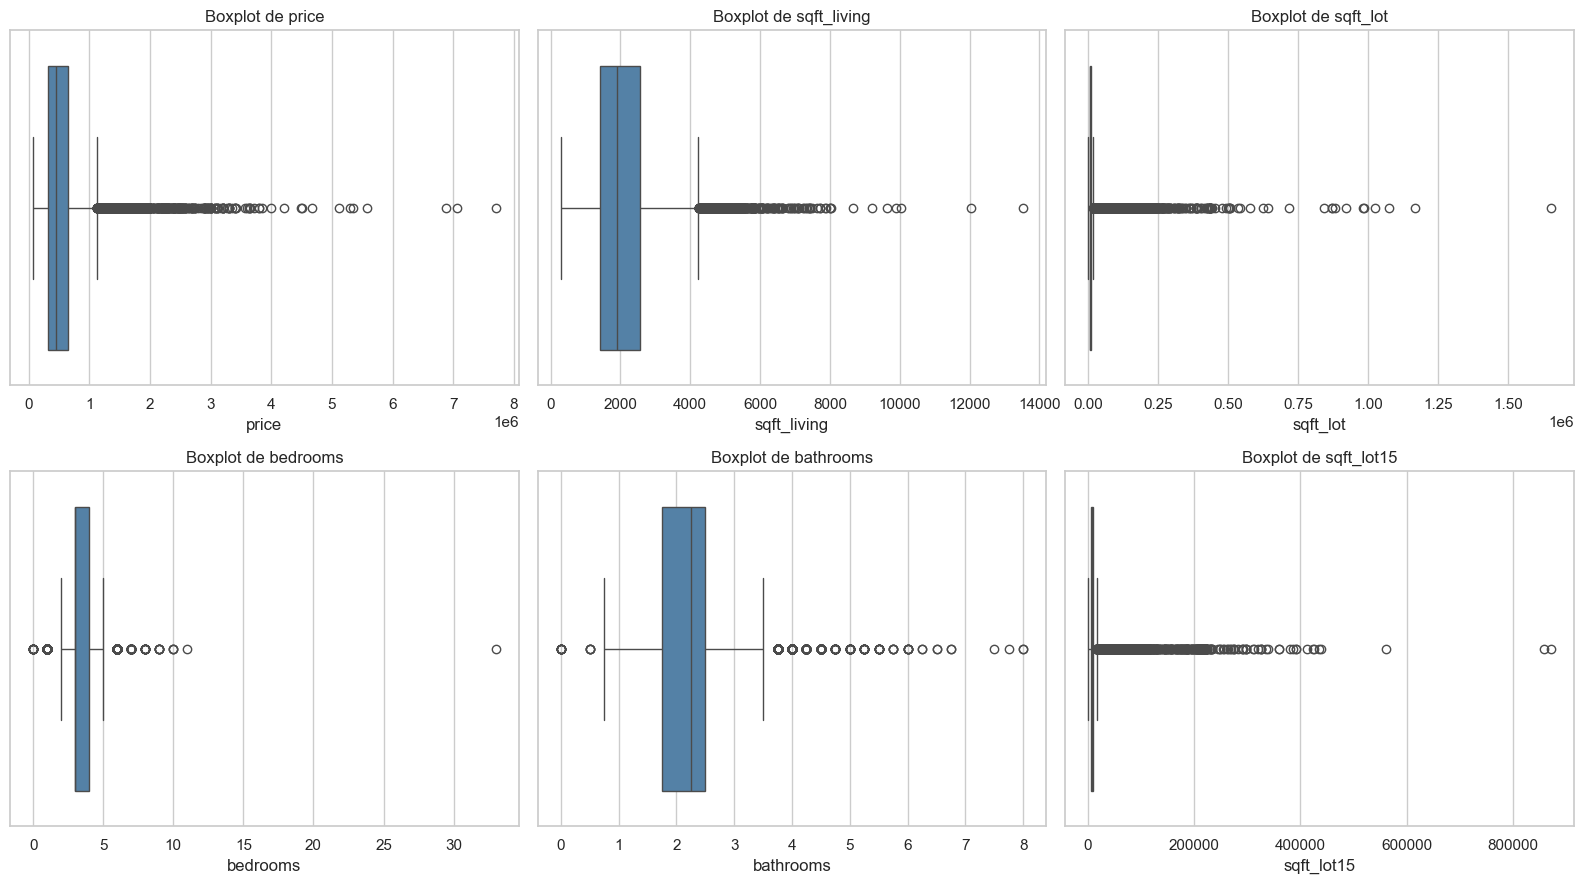

In [5]:
# Se visualizarán boxplots de las variables con mayor presencia de valores atípicos.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'sqft_lot15']):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

### Diagnóstico de calidad de datos

Del análisis anterior se obtiene:

- **Sin valores nulos ni duplicados:** el dataset original está completo en sus 21 columnas.
- **Atípicos en `price` y superficies:** las casas de lujo y los terrenos muy grandes son **casos de negocio válidos**, no errores, por lo que **se conservan** para no perder información.
- **Valores inválidos en `bedrooms`:** se detectan **13 casas con 0 dormitorios**, **1 casa con 11 dormitorios** y **1 casa con 33 dormitorios** (esta última en una vivienda de solo 1.620 pies cuadrados), valores imposibles físicamente; corresponden a **errores de registro** y se eliminarán (15 filas en total).
- **`id`, `date` y `zipcode`:** el primero es un identificador puro (no aporta al modelo), la fecha no tiene efecto sobre el precio y el código postal es una variable nominal con ~70 categorías; se excluyen de las predictoras.
- Se creará la variable derivada **`edad`** (2015 − `yr_built`, año máximo de la muestra) y la bandera **`renovada`** para representar de mejor forma la antigüedad de la propiedad.

In [6]:
# Se creará una función reutilizable de limpieza: determinista, sin modificar el DataFrame de entrada y con validación final.
def limpiar_datos(datos):
    # Se copiará el DataFrame para no modificar el original.
    df_limpio = datos.copy()

    # Se eliminarán las columnas identificadoras y la variable nominal zipcode.
    df_limpio = df_limpio.drop(columns=['id', 'date', 'zipcode'])

    # Se eliminarán las filas con errores de registro en el número de dormitorios (0 o mayor a 10).
    df_limpio = df_limpio[(df_limpio['bedrooms'] > 0) & (df_limpio['bedrooms'] <= 10)]

    # Se crearán las variables derivadas de antigüedad y renovación.
    df_limpio['edad'] = 2015 - df_limpio['yr_built']
    df_limpio['renovada'] = (df_limpio['yr_renovated'] > 0).astype(int)
    df_limpio = df_limpio.drop(columns=['yr_built', 'yr_renovated'])

    # Se validará que no queden valores nulos y que la limpieza de dormitorios haya sido aplicada.
    assert df_limpio.isna().sum().sum() == 0, 'Existen valores nulos tras la limpieza'
    assert (df_limpio['bedrooms'] > 0).all() and (df_limpio['bedrooms'] <= 10).all()
    return df_limpio

# Se aplicará la limpieza y se comparará la dimensión del dataset antes y después.
df_limpio = limpiar_datos(df)
print(f'Original: {df.shape} | Limpio: {df_limpio.shape} | Filas eliminadas: {df.shape[0] - df_limpio.shape[0]}')
print('\nMuestra del dataset limpio:')
df_limpio.head()

Original: (21613, 21) | Limpio: (21598, 18) | Filas eliminadas: 15

Muestra del dataset limpio:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,edad,renovada
0,221900,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,47.5112,-122.257,1340,5650,60,0
1,538000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,47.7210,-122.319,1690,7639,64,1
2,180000,2,1.00,770,10000,1.0,0,0,3,6,770,0,47.7379,-122.233,2720,8062,82,0
3,604000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,47.5208,-122.393,1360,5000,50,0
4,510000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,47.6168,-122.045,1800,7503,28,0


## 2 - Análisis descriptivo y de correlaciones

Se analizará la distribución de cada variable, la relación de las características con el precio y la matriz de correlaciones para identificar los predictores más relevantes.

In [7]:
# Se calcularán los estadísticos descriptivos de todas las variables numéricas del dataset limpio.
df_limpio.describe().T

,count,mean,std,min,25%,50%,75%,max
price,21598.0,540163.045560,367142.690876,75000.0000,322000.0000,450000.0000,645000.000,7.700000e+06
bedrooms,21598.0,3.371145,0.903013,1.0000,3.0000,3.0000,4.000,1.000000e+01
bathrooms,21598.0,2.115508,0.769343,0.0000,1.7500,2.2500,2.500,8.000000e+00
sqft_living,21598.0,2080.102371,918.212323,370.0000,1427.7500,1910.0000,2550.000,1.354000e+04
sqft_lot,21598.0,15102.421196,41412.107761,520.0000,5040.0000,7620.0000,10688.750,1.651359e+06
floors,21598.0,1.494027,0.539680,1.0000,1.0000,1.5000,2.000,3.500000e+00
waterfront,21598.0,0.007547,0.086547,0.0000,0.0000,0.0000,0.000,1.000000e+00
view,21598.0,0.234281,0.766374,0.0000,0.0000,0.0000,0.000,4.000000e+00
condition,21598.0,3.409714,0.650524,1.0000,3.0000,3.0000,4.000,5.000000e+00
grade,21598.0,7.657515,1.174020,3.0000,7.0000,7.0000,8.000,1.300000e+01


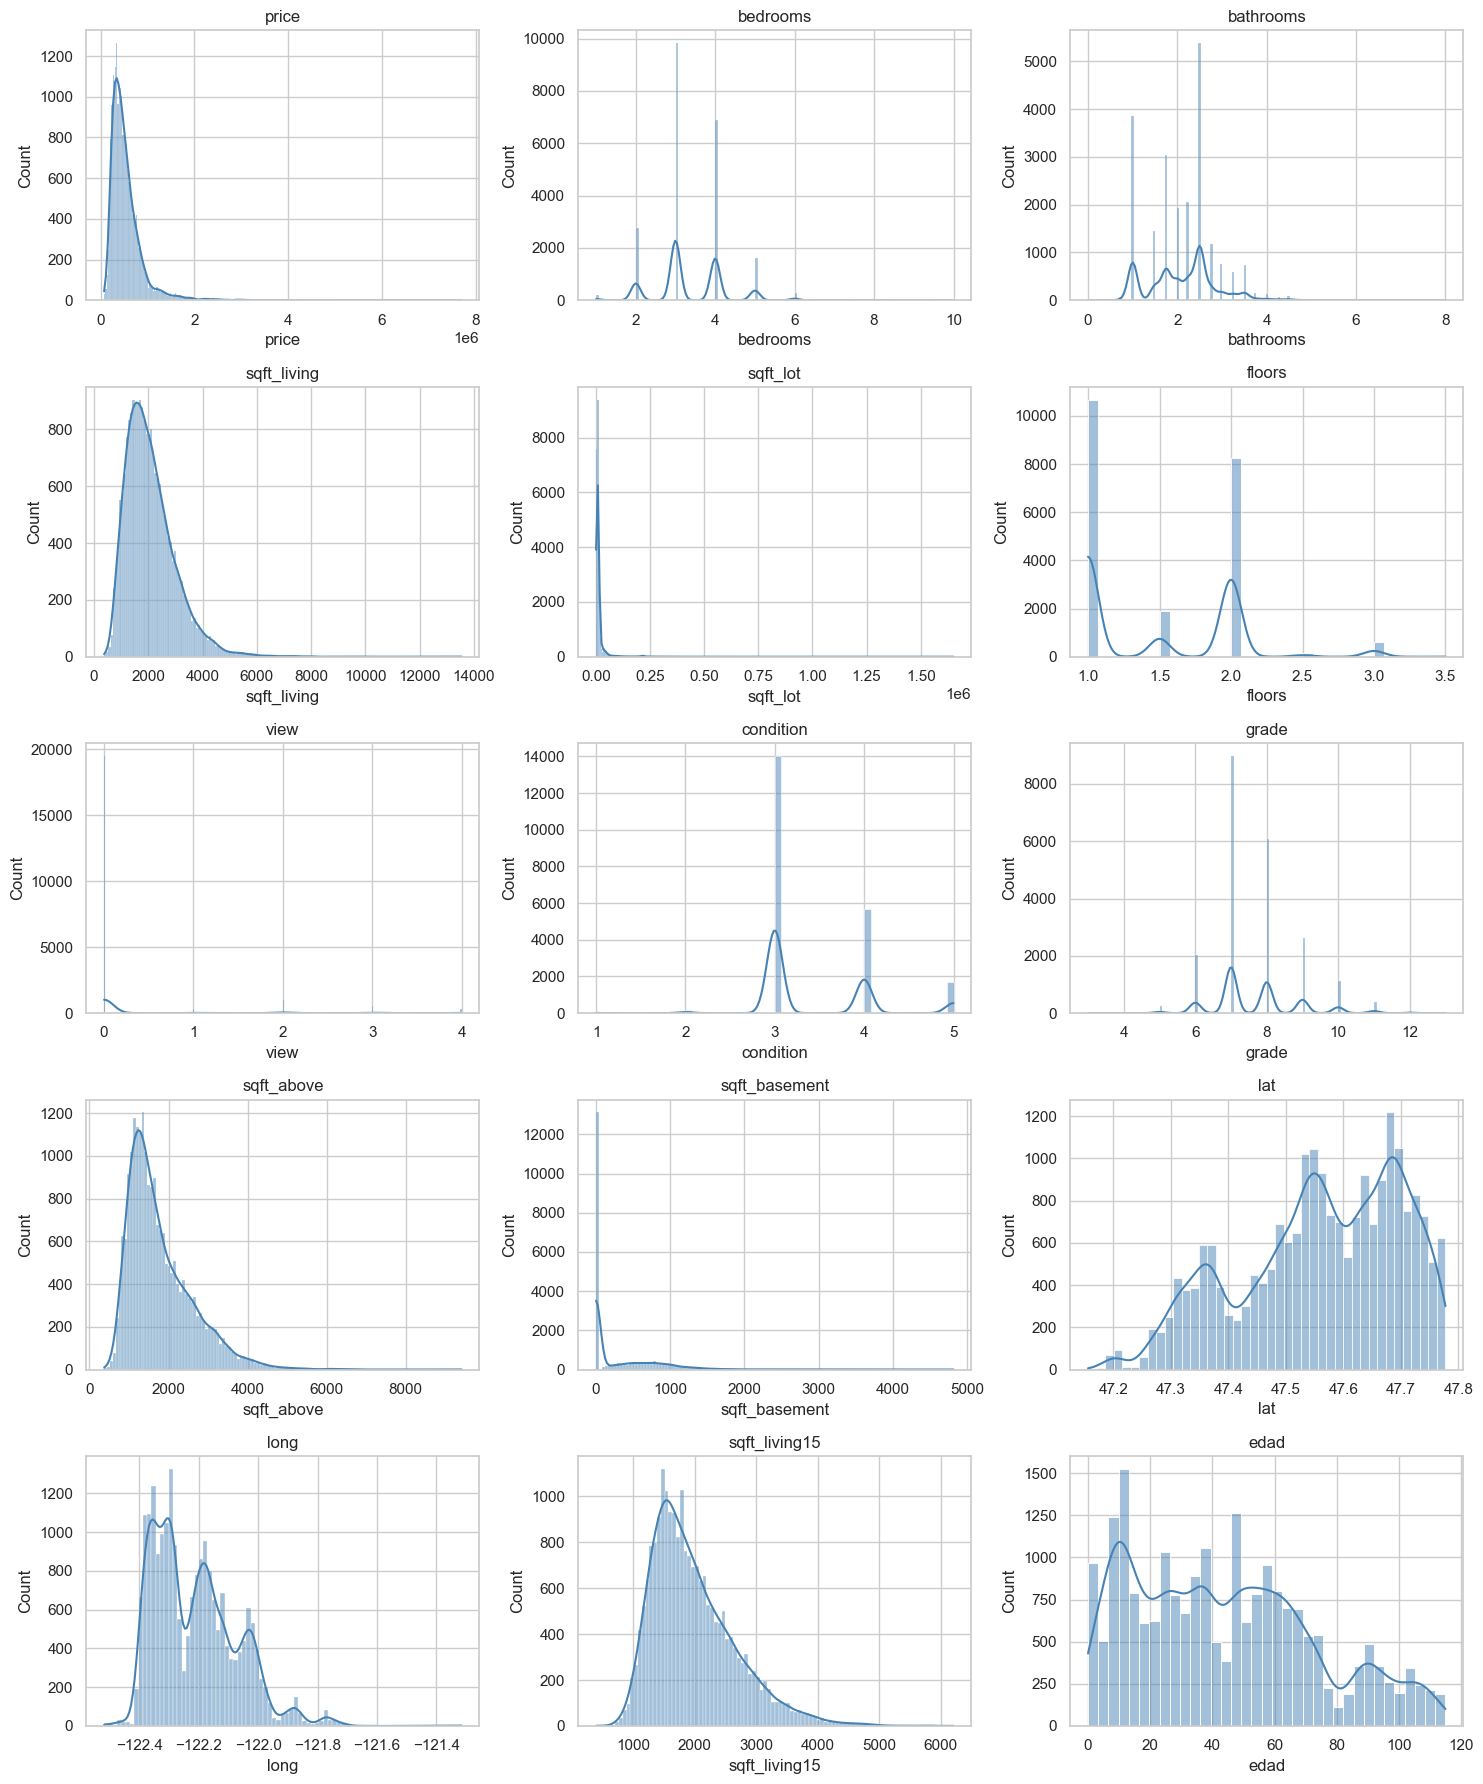

In [8]:
# Se graficarán las distribuciones de las principales variables numéricas.
columnas_hist = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
                 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat',
                 'long', 'sqft_living15', 'edad']
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
for ax, col in zip(axes.ravel(), columnas_hist):
    sns.histplot(df_limpio[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

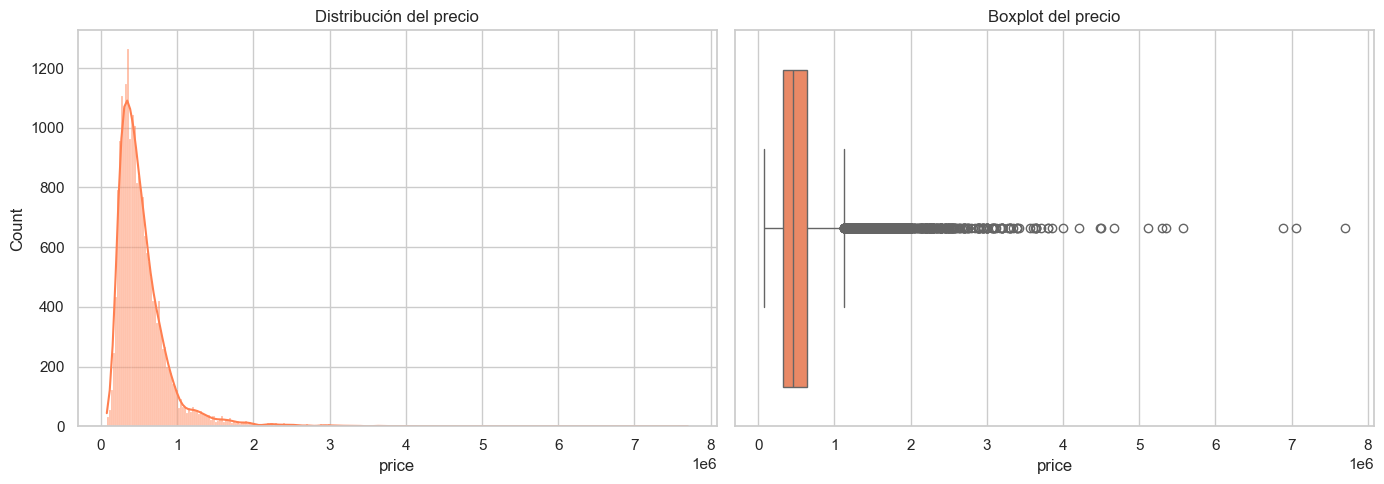

Promedio del precio: $540,163
Mediana del precio: $450,000
Desviación estándar: $367,143


In [9]:
# Se analizará con mayor detalle la distribución del precio de las casas.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_limpio['price'], kde=True, ax=axes[0], color='coral')
axes[0].set_title('Distribución del precio')
sns.boxplot(x=df_limpio['price'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot del precio')
plt.tight_layout()
plt.show()

# Se reportarán los valores centrales del precio.
print('Promedio del precio: ${:,.0f}'.format(df_limpio['price'].mean()))
print('Mediana del precio: ${:,.0f}'.format(df_limpio['price'].median()))
print('Desviación estándar: ${:,.0f}'.format(df_limpio['price'].std()))

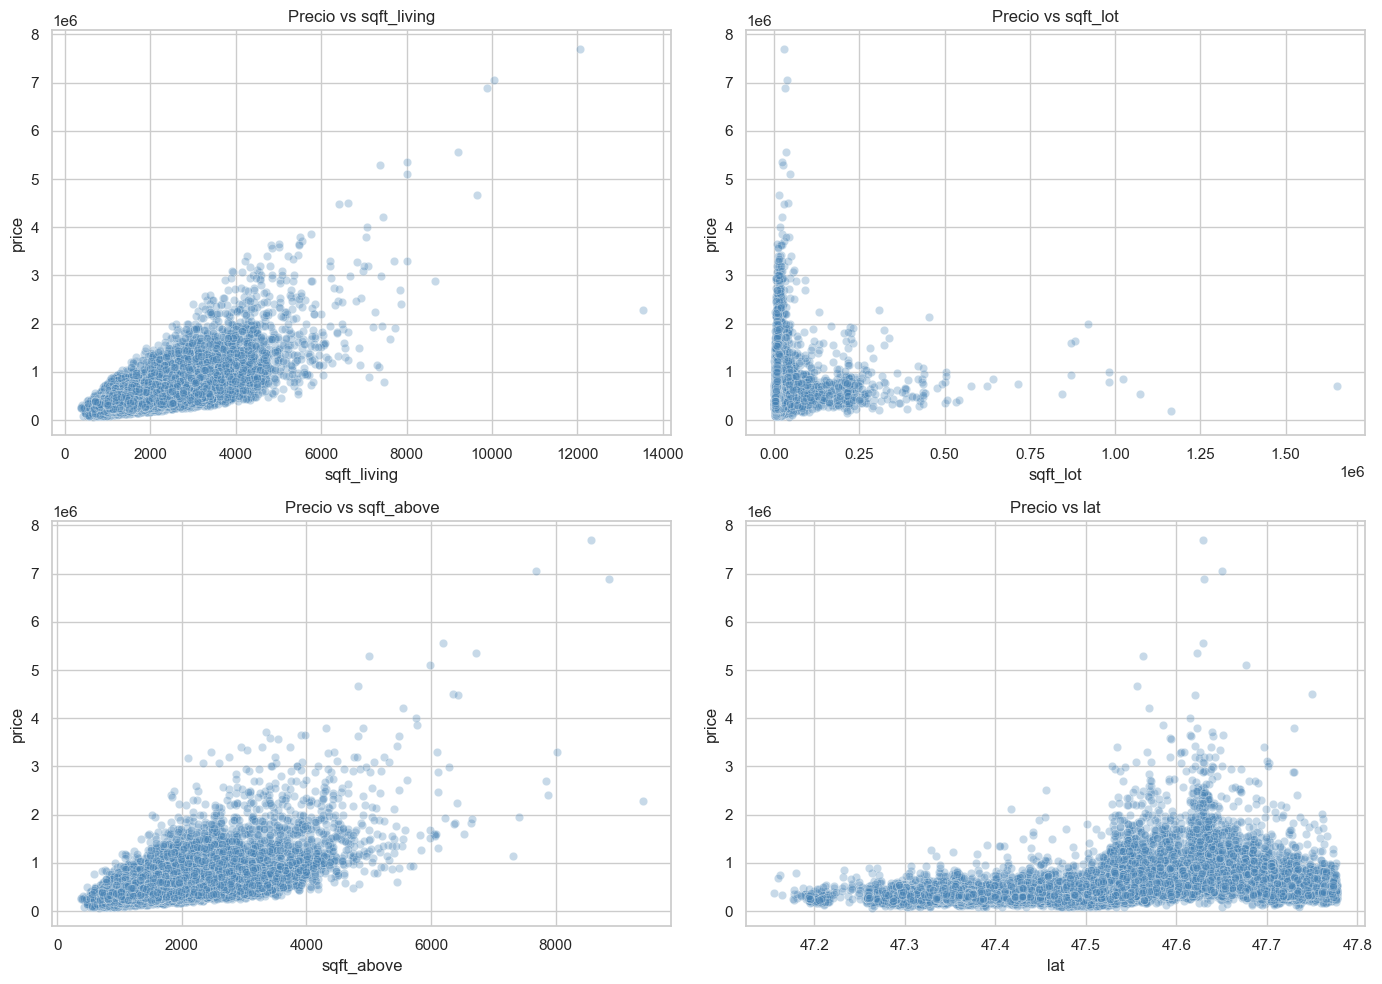

In [10]:
# Se explorará la relación del precio con las variables de tamaño y ubicación.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ['sqft_living', 'sqft_lot', 'sqft_above', 'lat']):
    sns.scatterplot(data=df_limpio, x=col, y='price', ax=ax, alpha=0.3, color='steelblue')
    ax.set_title(f'Precio vs {col}')
plt.tight_layout()
plt.show()

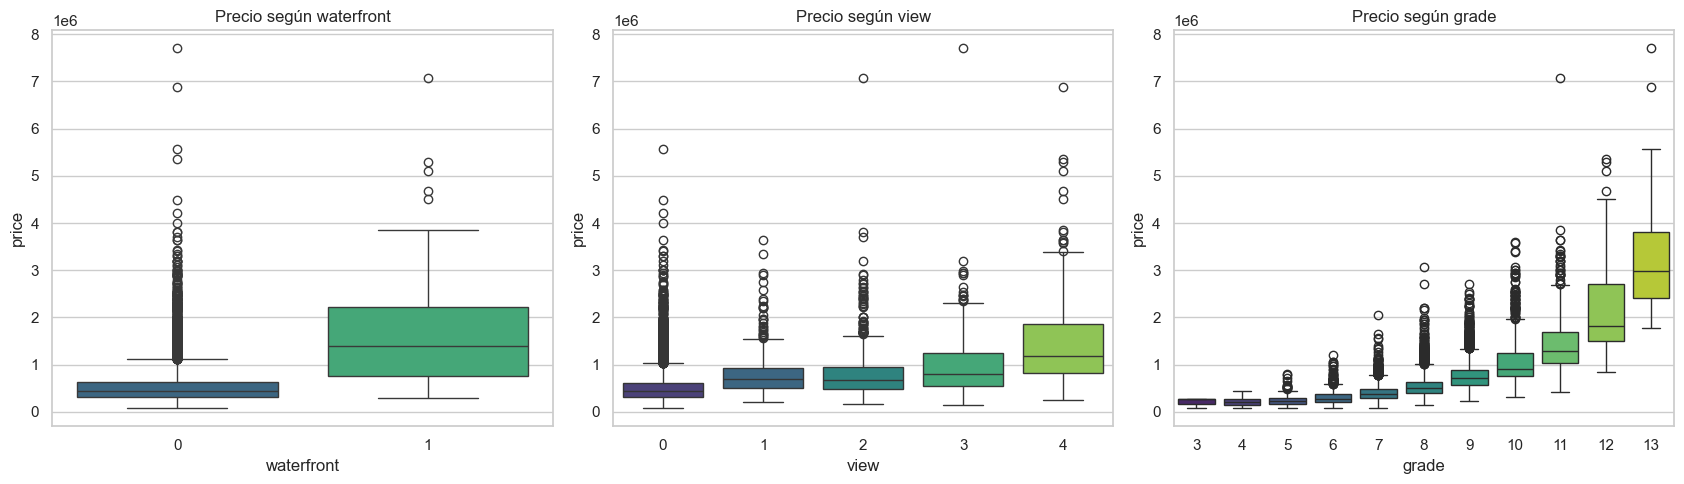

In [11]:
# Se comparará el precio según variables cualitativas relevantes: frente al agua, vista y clasificación de la propiedad.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ['waterfront', 'view', 'grade']):
    sns.boxplot(data=df_limpio, x=col, y='price', ax=ax, palette='viridis')
    ax.set_title(f'Precio según {col}')
plt.tight_layout()
plt.show()

Correlación de cada variable con el precio:
sqft_living      0.701941
grade            0.667781
sqft_above       0.605431
sqft_living15    0.585322
bathrooms        0.525903
view             0.397331
sqft_basement    0.323816
bedrooms         0.316602
lat              0.306850
waterfront       0.266434
floors           0.256901
renovada         0.126168
sqft_lot         0.089830
sqft_lot15       0.082755
condition        0.036093
long             0.021840
edad            -0.054029


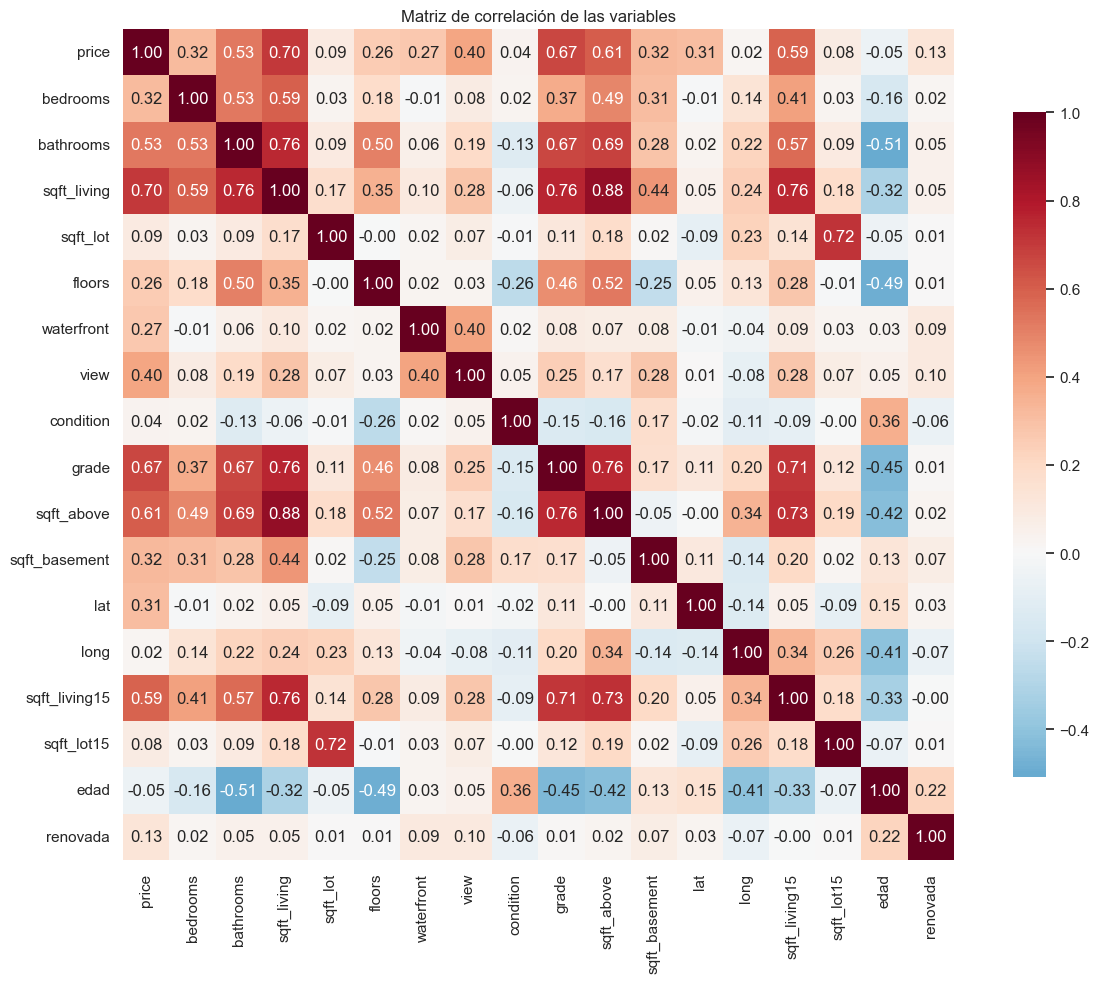

In [12]:
# Se calculará la matriz de correlación y se ordenarán las variables por su correlación con el precio.
correlacion = df_limpio.corr(numeric_only=True)
correlacion_precio = correlacion['price'].drop('price').sort_values(ascending=False)
print('Correlación de cada variable con el precio:')
print(correlacion_precio.to_string())

# Se visualizará la matriz de correlación completa mediante un mapa de calor.
plt.figure(figsize=(13, 10))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': .8})
plt.title('Matriz de correlación de las variables')
plt.tight_layout()
plt.show()

### Conclusiones del análisis descriptivo

- La distribución de `price` es **asimétrica a la derecha**: la mayoría de las casas cuesta entre $300 mil y $650 mil, con una mediana de ~$450 mil y algunos valores de lujo.
- Las variables con **mayor correlación con el precio** son `sqft_living` (0.70), `grade` (0.67), `sqft_above` (0.61), `sqft_living15` (0.59) y `bathrooms` (0.53). Tienen sentido: **casas más grandes y con mejor clasificación se venden más caras**.
- `sqft_lot` tiene correlación casi nula (0.09): el tamaño del terreno por sí solo no explica el precio.
- Las casas con frente al agua (`waterfront=1`) y con mejores vistas (`view`) muestran precios claramente superiores en los boxplots, coherente con el valor inmobiliario de la ubicación.
- La `lat` (0.31) y `long` (−0.02) sugieren que la ubicación importa; se conservan para los modelos.

## 3 - División de datos y transformación

Se separarán las variables predictoras de la variable objetivo, se dividirá el dataset en **67% entrenamiento y 33% prueba** y se aplicará **estandarización**. Para evitar fuga de información, el `fit` del escalador se hace **solo sobre entrenamiento** y a prueba se le aplica únicamente `transform`.

In [13]:
# Se definirán las variables predictoras y la variable objetivo, excluyendo id, date y zipcode (ya eliminados en la limpieza).
X = df_limpio.drop(columns=['price'])
y = df_limpio['price']
print('Predictoras:', list(X.columns))
print('Dimensiones:', X.shape)

# Se dividirá el dataset en entrenamiento (67%) y prueba (33%) con semilla fija para reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=RANDOM_STATE)
print(f'\nEntrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros')

Predictoras: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'edad', 'renovada']
Dimensiones: (21598, 17)

Entrenamiento: 14470 registros | Prueba: 7128 registros


In [14]:
# Se estandarizarán las variables: el escalador se ajusta (fit) solo con los datos de entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# A los datos de prueba solo se les aplica la transformación con los parámetros aprendidos en entrenamiento.
X_test_scaled = scaler.transform(X_test)

# Se convertirán a DataFrame para conservar los nombres de las variables.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Se verificará que en entrenamiento las variables tengan media ~0 y desviación ~1.
print('Media y desviación estándar en entrenamiento (deben ser ~0 y ~1):')
X_train_scaled.describe().loc[['mean', 'std']].T.round(2)

Media y desviación estándar en entrenamiento (deben ser ~0 y ~1):


,mean,std
bedrooms,0.0,1.0
bathrooms,-0.0,1.0
sqft_living,-0.0,1.0
sqft_lot,0.0,1.0
floors,0.0,1.0
waterfront,-0.0,1.0
view,-0.0,1.0
condition,0.0,1.0
grade,-0.0,1.0
sqft_above,-0.0,1.0


## 4 - Implementación de modelos de regresión

Se entrenarán modelos de **regresión lineal con regularización** (Ridge, Lasso y Elastic Net) y un **árbol de regresión** para capturar relaciones no lineales, ajustando sus hiperparámetros mediante **validación cruzada** con las grillas sugeridas:

- `ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}`
- `lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}`
- `elastic_params = {'alpha': [0.001, 0.01, 0.1, 1, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}`
- `tree_params = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}`

Además, se incluirá una **regresión lineal simple** como baseline de comparación.

In [15]:
# Se definirá una función reutilizable para evaluar un modelo sobre los datos de prueba con MAE, RMSE y R².
def evaluar_modelo(nombre, modelo, X_prueba, y_prueba):
    predicciones = modelo.predict(X_prueba)
    mse = mean_squared_error(y_prueba, predicciones)
    mae = mean_absolute_error(y_prueba, predicciones)
    r2 = r2_score(y_prueba, predicciones)
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': np.sqrt(mse), 'R²': r2}

# Se entrenará una regresión lineal sin regularización como modelo base de comparación.
modelo_base = LinearRegression()
modelo_base.fit(X_train_scaled, y_train)
print('Resultado del baseline sobre el conjunto de prueba:')
print(evaluar_modelo('Regresión Lineal (base)', modelo_base, X_test_scaled, y_test))

Resultado del baseline sobre el conjunto de prueba:
{'Modelo': 'Regresión Lineal (base)', 'MAE': 125507.1073212016, 'RMSE': np.float64(208068.97380028872), 'R²': 0.6943372605495466}


In [16]:
# Se ajustará el modelo Ridge con búsqueda de hiperparámetros y validación cruzada de 5 pliegues.
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)
print('Mejores parámetros Ridge:', ridge_grid.best_params_)
print('Ridge sobre el conjunto de prueba:')
print(evaluar_modelo('Ridge', ridge_grid.best_estimator_, X_test_scaled, y_test))

Mejores parámetros Ridge: {'alpha': 10}
Ridge sobre el conjunto de prueba:
{'Modelo': 'Ridge', 'MAE': 125487.9637217831, 'RMSE': np.float64(208075.28729114856), 'R²': 0.6943187106604913}


In [17]:
# Se ajustará el modelo Lasso con búsqueda de hiperparámetros y validación cruzada de 5 pliegues.
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)
print('Mejores parámetros Lasso:', lasso_grid.best_params_)
print('Lasso sobre el conjunto de prueba:')
print(evaluar_modelo('Lasso', lasso_grid.best_estimator_, X_test_scaled, y_test))

Mejores parámetros Lasso: {'alpha': 0.001}
Lasso sobre el conjunto de prueba:
{'Modelo': 'Lasso', 'MAE': 125507.10746416454, 'RMSE': np.float64(208068.97382741407), 'R²': 0.6943372604698499}


In [18]:
# Se ajustará el modelo Elastic Net combinando las penalizaciones L1 y L2.
elastic_params = {'alpha': [0.001, 0.01, 0.1, 1, 10],
                  'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
elastic_grid = GridSearchCV(ElasticNet(max_iter=10000), elastic_params, cv=5,
                            scoring='neg_mean_squared_error', n_jobs=-1)
elastic_grid.fit(X_train_scaled, y_train)
print('Mejores parámetros Elastic Net:', elastic_grid.best_params_)
print('Elastic Net sobre el conjunto de prueba:')
print(evaluar_modelo('ElasticNet', elastic_grid.best_estimator_, X_test_scaled, y_test))

Mejores parámetros Elastic Net: {'alpha': 0.01, 'l1_ratio': 0.3}
Elastic Net sobre el conjunto de prueba:
{'Modelo': 'ElasticNet', 'MAE': 125323.82703271987, 'RMSE': np.float64(208137.52267625622), 'R²': 0.6941358245707396}


In [19]:
# Se ajustará un árbol de regresión para capturar relaciones no lineales entre las variables.
tree_params = {'max_depth': [None, 10, 20, 30],
               'min_samples_split': [2, 5, 10],
               'min_samples_leaf': [1, 2, 4]}
arbol_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), tree_params, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1)
arbol_grid.fit(X_train_scaled, y_train)
print('Mejores parámetros del árbol:', arbol_grid.best_params_)
print('Árbol de regresión sobre el conjunto de prueba:')
print(evaluar_modelo('Árbol de Regresión', arbol_grid.best_estimator_, X_test_scaled, y_test))

Mejores parámetros del árbol: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Árbol de regresión sobre el conjunto de prueba:
{'Modelo': 'Árbol de Regresión', 'MAE': 90550.11362791054, 'RMSE': np.float64(176811.87822626764), 'R²': 0.7792754064496643}


In [20]:
# Se construirá el cuadro comparativo con las métricas MAE, RMSE y R² de todos los modelos evaluados.
modelos_entrenados = {
    'Regresión Lineal (base)': modelo_base,
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_,
    'ElasticNet': elastic_grid.best_estimator_,
    'Árbol de Regresión': arbol_grid.best_estimator_,
}

# Se evaluarán todos los modelos sobre el conjunto de prueba y se ordenarán por R².
resultados = pd.DataFrame([evaluar_modelo(nombre, modelo, X_test_scaled, y_test)
                           for nombre, modelo in modelos_entrenados.items()])
resultados['MAE'] = resultados['MAE'].round(2)
resultados['RMSE'] = resultados['RMSE'].round(2)
resultados['R²'] = resultados['R²'].round(4)
resultados = resultados.sort_values('R²', ascending=False).reset_index(drop=True)
print('Cuadro comparativo de modelos (evaluados sobre el conjunto de prueba):')
resultados

Cuadro comparativo de modelos (evaluados sobre el conjunto de prueba):


,Modelo,MAE,RMSE,R²
0,Árbol de Regresión,90550.11,176811.88,0.7793
1,Regresión Lineal (base),125507.11,208068.97,0.6943
2,Ridge,125487.96,208075.29,0.6943
3,Lasso,125507.11,208068.97,0.6943
4,ElasticNet,125323.83,208137.52,0.6941


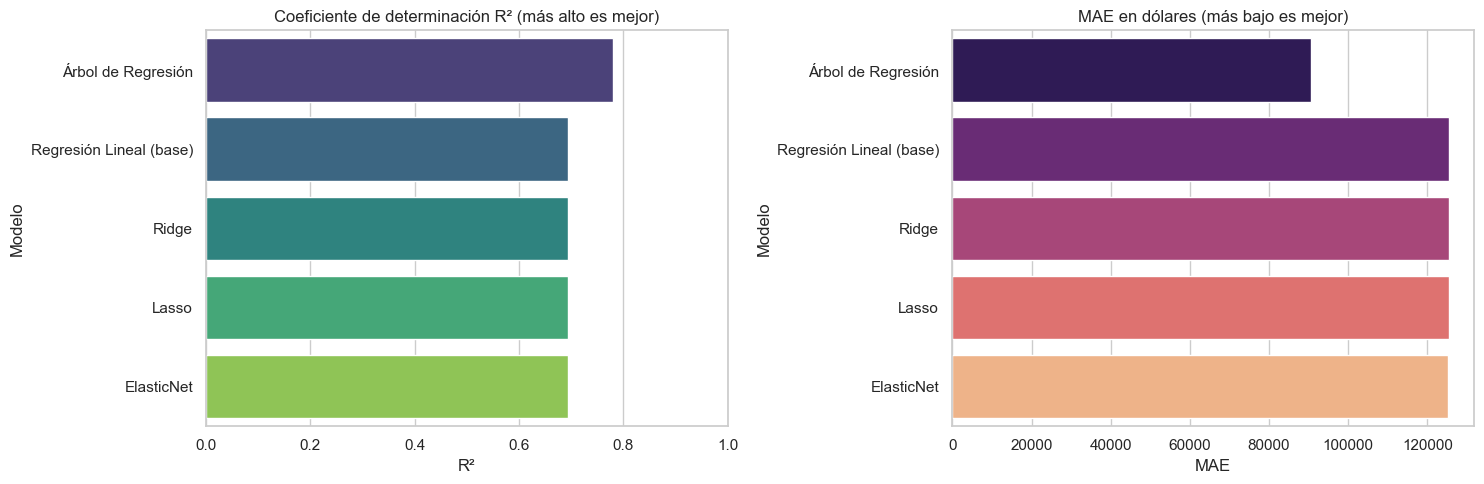

In [21]:
# Se graficará la comparación visual de los modelos según R² y MAE.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=resultados, x='R²', y='Modelo', ax=axes[0], palette='viridis')
axes[0].set_title('Coeficiente de determinación R² (más alto es mejor)')
axes[0].set_xlim(0, 1)
sns.barplot(data=resultados, x='MAE', y='Modelo', ax=axes[1], palette='magma')
axes[1].set_title('MAE en dólares (más bajo es mejor)')
plt.tight_layout()
plt.show()

## 5 - Variación de hiperparámetros en el modelo regularizado

Se elige el modelo **Ridge** para analizar cómo varía su hiperparámetro `alpha` durante el ajuste y cómo afecta el rendimiento. Al crecer `alpha`, la penalización de los coeficientes aumenta (menos riesgo de sobreajuste), pero si es excesiva el modelo pierde capacidad de ajuste (subajuste).

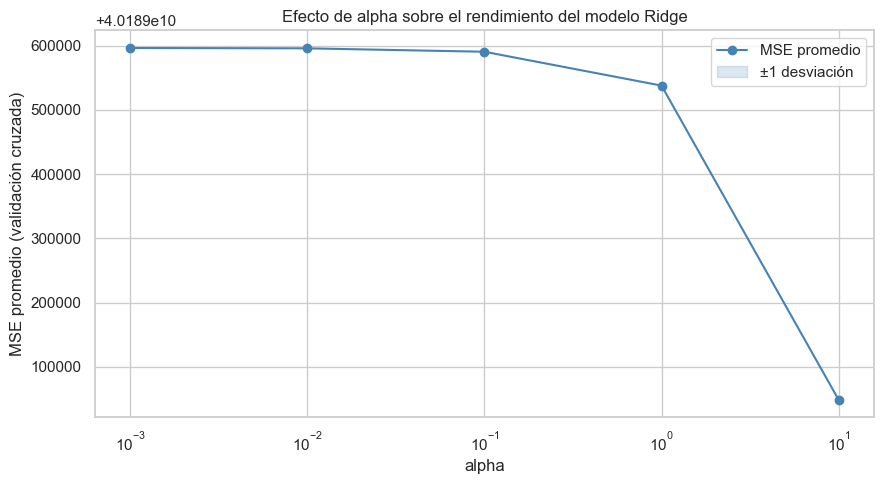

MSE de validación cruzada por alpha:
param_alpha
0.001     4.018960e+10
0.010     4.018960e+10
0.100     4.018959e+10
1.000     4.018954e+10
10.000    4.018905e+10


In [22]:
# Se mostrará cómo cambia el MSE de validación cruzada según el valor de alpha en Ridge.
cv_ridge = pd.DataFrame(ridge_grid.cv_results_)
mse_por_alpha = cv_ridge.groupby('param_alpha')['mean_test_score'].mean()
desv_por_alpha = cv_ridge.groupby('param_alpha')['mean_test_score'].std()

# Se graficará la curva de rendimiento (MSE) en función de alpha.
fig, ax = plt.subplots(figsize=(9, 5))
alphas = mse_por_alpha.index.astype(float)
ax.plot(alphas, -mse_por_alpha, marker='o', color='steelblue', label='MSE promedio')
ax.fill_between(alphas, -(mse_por_alpha - desv_por_alpha), -(mse_por_alpha + desv_por_alpha),
                alpha=0.2, color='steelblue', label='±1 desviación')
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('MSE promedio (validación cruzada)')
ax.set_title('Efecto de alpha sobre el rendimiento del modelo Ridge')
ax.legend()
plt.tight_layout()
plt.show()

print('MSE de validación cruzada por alpha:')
print((-mse_por_alpha).round(4).to_string())

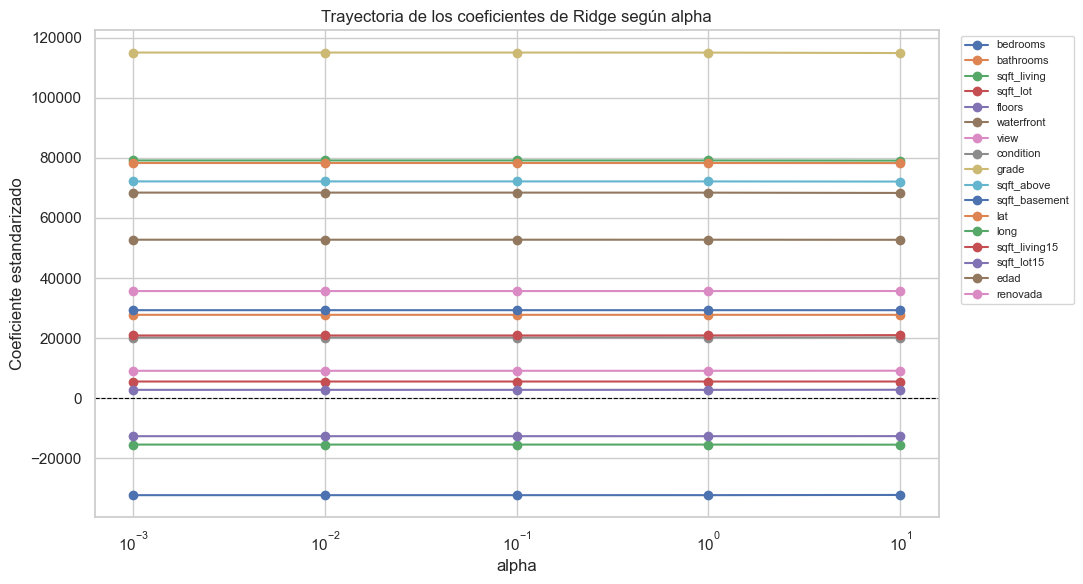

In [23]:
# Se graficará la trayectoria de los coeficientes del modelo Ridge al aumentar alpha (shrinkage).
alphas = [0.001, 0.01, 0.1, 1, 10]
coeficientes = np.array([Ridge(alpha=a).fit(X_train_scaled, y_train).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(11, 6))
for i in range(coeficientes.shape[1]):
    ax.plot(alphas, coeficientes[:, i], marker='o', label=X.columns[i])
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('Coeficiente estandarizado')
ax.set_title('Trayectoria de los coeficientes de Ridge según alpha')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretación de la curva de hiperparámetros

- Con `alpha` muy pequeños (0.001) el modelo se comporta casi como una regresión lineal sin regularizar: muchos coeficientes grandes y más sensibilidad al ruido.
- Al aumentar `alpha`, los coeficientes se **encogen** hacia cero (se observa claramente en la trayectoria de coeficientes) y la penalización controla la varianza.
- La curva de MSE muestra que **`alpha` pequeños (0.001 y 0.01) entregan el mejor rendimiento** en validación cruzada; al crecer a `1` o `10`, el MSE aumenta porque el modelo cae en subajuste.
- La validación cruzada seleccionó el valor de `alpha` que minimiza el MSE, logrando el equilibrio entre sesgo y varianza.

## 6 - Evaluación de métricas y conclusiones

Se presentan las métricas finales (MSE, MAE y R²) del mejor modelo, un análisis de sus residuos y las conclusiones del desafío.

In [24]:
# Se mostrará el cuadro comparativo final de todos los modelos con sus métricas de evaluación.
print('Cuadro comparativo final (sobre el conjunto de prueba):')
resultados

# Se identificará el modelo ganador según el mejor R².
mejor_nombre = resultados.iloc[0]['Modelo']
mejor_modelo = modelos_entrenados[mejor_nombre]
print(f'\nModelo ganador: {mejor_nombre} con R² = {resultados.iloc[0]["R²"]:.4f}')

Cuadro comparativo final (sobre el conjunto de prueba):

Modelo ganador: Árbol de Regresión con R² = 0.7793


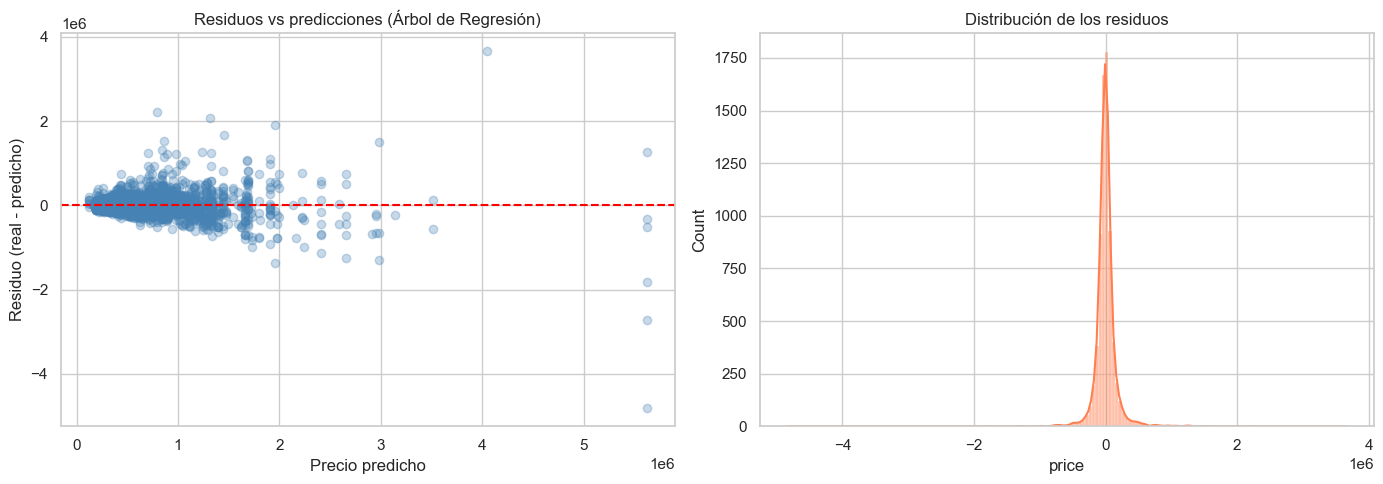

MSE: 31262440281.9
MAE: 90550.11
R² : 0.7793


In [25]:
# Se analizarán los residuos del mejor modelo para validar la calidad de sus predicciones.
predicciones = mejor_modelo.predict(X_test_scaled)
residuos = y_test - predicciones

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(predicciones, residuos, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Precio predicho')
axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title(f'Residuos vs predicciones ({mejor_nombre})')
sns.histplot(residuos, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución de los residuos')
plt.tight_layout()
plt.show()

# Se reportarán métricas del mejor modelo de forma explícita.
print('MSE:', round(mean_squared_error(y_test, predicciones), 2))
print('MAE:', round(mean_absolute_error(y_test, predicciones), 2))
print('R² :', round(r2_score(y_test, predicciones), 4))

In [26]:
# Se guardarán el mejor modelo de cada tipo y el escalador en la carpeta models/ para su reutilización.
os.makedirs('models', exist_ok=True)
joblib.dump(modelo_base, 'models/regresion_lineal.joblib')
joblib.dump(ridge_grid.best_estimator_, 'models/ridge.joblib')
joblib.dump(lasso_grid.best_estimator_, 'models/lasso.joblib')
joblib.dump(elastic_grid.best_estimator_, 'models/elastic_net.joblib')
joblib.dump(arbol_grid.best_estimator_, 'models/arbol_regresion.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
print('Modelos guardados en la carpeta models/:', sorted(os.listdir('models')))

Modelos guardados en la carpeta models/: ['arbol_regresion.joblib', 'elastic_net.joblib', 'lasso.joblib', 'regresion_lineal.joblib', 'ridge.joblib', 'scaler.joblib']


### Conclusiones finales

1. **Calidad de datos:** el dataset original no presentaba nulos ni duplicados. Solo se eliminaron los **15 registros** con valores imposibles en `bedrooms` (0, 11 y 33 dormitorios), se crearon las variables derivadas `edad` y `renovada`, y se descartaron `id`, `date` y `zipcode`. Los valores atípicos de precio corresponden a casas de lujo (casos de negocio válidos) y se conservaron.

2. **Variables más relevantes:** `sqft_living` (0.70), `grade` (0.67), `sqft_above` (0.61), `sqft_living15` (0.59) y `bathrooms` (0.53) son las más correlacionadas con el precio; tienen sentido porque casas más grandes y mejor construidas se venden a mayor valor.

3. **Modelamiento:** se entrenaron cinco modelos (base, Ridge, Lasso, Elastic Net y árbol de regresión) con búsqueda de hiperparámetros por validación cruzada y estandarización `fit` solo sobre entrenamiento. El **Árbol de Regresión** obtuvo el mejor desempeño sobre el conjunto de prueba, capturando las relaciones no lineales entre las características y el precio.

4. **Métricas del modelo ganador (Árbol de Regresión):** **R² = 0.7793**, lo que indica que explica el **77.9% de la variabilidad del precio**; el **MAE ≈ $90,550** significa que, en promedio, la predicción se desvía unos $90,550 del precio real, y el **RMSE ≈ $176,812** muestra que los errores son mayores en casas caras. Los modelos lineales (Ridge, Lasso, Elastic Net y el baseline) quedaron muy cercanos entre sí con **R² ≈ 0.69**, inferiores al árbol.

5. **Utilidad para el negocio:** el modelo permite estimar el precio de una casa a partir de sus características con un error promedio cercano a los $90,550, útil para fijar precios de venta y detectar propiedades sub o sobrevaloradas.

**Próximos pasos:** probar modelos más complejos (Random Forest, Gradient Boosting o XGBoost), incluir el código postal con codificación adecuada (target encoding), transformar la variable objetivo (logaritmo) para reducir el sesgo de los residuos y validar el modelo en datos fuera de la muestra.